In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:
from sklearn.datasets import make_blobs

In [5]:
X,y=make_blobs(n_samples=1000,n_features=2,centers=3)

In [6]:
X

array([[ 7.82588054, -7.19367755],
       [11.10551038, -6.49915172],
       [10.83237456, -7.14090094],
       ...,
       [-1.17313252,  0.53651292],
       [ 7.82534389, -6.98631027],
       [-1.29890963,  3.07623555]], shape=(1000, 2))

In [7]:
y

array([1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 2, 2, 1, 1, 2, 0, 1, 0, 2, 1, 1, 0,
       2, 2, 1, 2, 1, 2, 2, 0, 2, 2, 1, 1, 0, 1, 2, 2, 2, 2, 2, 0, 2, 0,
       1, 1, 1, 1, 0, 1, 2, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 1, 0, 2, 1,
       2, 2, 0, 0, 0, 2, 2, 1, 0, 1, 1, 1, 1, 2, 2, 1, 0, 1, 0, 2, 0, 1,
       2, 2, 2, 1, 0, 2, 0, 1, 1, 0, 1, 1, 2, 0, 1, 2, 2, 1, 1, 1, 2, 2,
       0, 2, 2, 0, 1, 0, 2, 0, 2, 1, 2, 2, 1, 0, 2, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2, 1, 0, 1, 0, 0, 1, 1, 0, 2, 2, 2, 1, 1, 2,
       2, 2, 2, 1, 1, 2, 2, 1, 0, 0, 2, 0, 1, 0, 2, 1, 1, 0, 2, 2, 0, 2,
       1, 1, 0, 2, 0, 1, 2, 0, 0, 2, 0, 0, 1, 2, 1, 0, 1, 1, 0, 2, 1, 2,
       1, 1, 1, 2, 0, 2, 2, 1, 1, 2, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 2, 1,
       2, 0, 1, 0, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1, 0, 2, 1, 1, 2, 1, 2, 0,
       0, 1, 2, 1, 0, 2, 1, 1, 0, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 0, 1, 1,
       2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 0, 2, 2, 0,

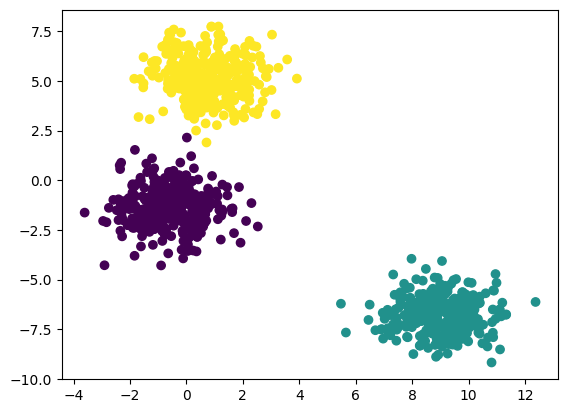

In [8]:
plt.scatter(X[:,0],X[:,1],c=y)

In [9]:
##standardization or feature scaling 


from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [12]:
X_train_scaled=scaler.fit_transform(X_train)

In [13]:
X_test_scaled=scaler.transform(X_test)

In [14]:
from  sklearn.cluster import KMeans

In [15]:
#Elbow method to select k value 
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)


In [16]:
wcss

[1340.0000000000005,
 267.4949848414587,
 64.84017698976913,
 55.451083185340536,
 48.0052846899324,
 44.728680600347374,
 35.18600292168018,
 34.64228052499592,
 29.2200273288902,
 26.519037412511096]

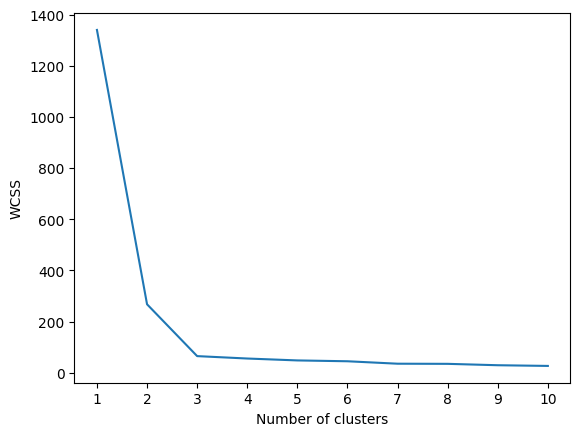

In [17]:
#plot elbow curve 

plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [18]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [19]:
kmeans.fit_predict(X_train_scaled)

array([0, 0, 0, 0, 1, 2, 1, 0, 2, 2, 1, 1, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2,
       2, 0, 2, 0, 0, 2, 2, 2, 1, 0, 2, 2, 1, 2, 2, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 2, 1, 0, 2, 1, 0, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 2, 2, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 2, 2, 0, 2, 1, 2, 1, 2, 0, 1, 0, 2, 0,
       2, 1, 2, 0, 1, 0, 1, 1, 1, 2, 0, 0, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2,
       2, 0, 1, 2, 0, 0, 2, 2, 2, 0, 2, 2, 1, 0, 2, 2, 1, 2, 1, 2, 0, 0,
       2, 1, 1, 2, 1, 0, 1, 1, 1, 0, 0, 2, 0, 2, 1, 1, 1, 2, 0, 0, 2, 2,
       1, 0, 2, 1, 1, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 0, 0, 0,
       1, 0, 1, 0, 2, 0, 0, 0, 2, 0, 1, 1, 0, 2, 1, 2, 0, 2, 2, 2, 2, 1,
       1, 2, 1, 0, 0, 1, 2, 2, 2, 1, 2, 0, 1, 1, 1, 1, 0, 1, 2, 2, 0, 1,
       2, 0, 0, 0, 1, 1, 0, 0, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 2,
       0, 2, 2, 1, 2, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 2, 2, 2, 0, 2, 1, 1,
       0, 1, 2, 1, 2, 0, 0, 0, 2, 1, 1, 2, 2, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 2, 1, 0, 2, 1, 0, 0, 0, 0, 1, 0,

In [20]:
y_pred=kmeans.predict(X_test_scaled)

In [21]:
y_pred

array([2, 1, 2, 2, 0, 1, 2, 2, 0, 0, 0, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 1,
       1, 2, 1, 0, 0, 0, 0, 1, 0, 2, 0, 2, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       2, 1, 0, 2, 2, 1, 1, 1, 1, 0, 2, 2, 2, 2, 1, 1, 2, 0, 0, 0, 0, 0,
       2, 1, 0, 2, 1, 2, 1, 0, 0, 1, 0, 2, 2, 0, 1, 2, 1, 2, 1, 2, 1, 1,
       0, 1, 1, 2, 2, 1, 0, 2, 1, 2, 0, 2, 1, 2, 0, 0, 2, 0, 1, 0, 1, 2,
       0, 2, 2, 1, 0, 0, 0, 1, 0, 0, 2, 0, 1, 2, 1, 1, 2, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1, 0, 2, 2, 2, 0, 2,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 1, 2, 2, 2, 1, 2, 1, 2, 0, 1, 2, 1, 2, 0, 0, 1, 0, 1, 1, 0,
       2, 1, 0, 0, 1, 2, 0, 0, 0, 0, 1, 0, 1, 2, 0, 0, 2, 2, 0, 0, 0, 1,
       0, 1, 1, 1, 2, 1, 0, 0, 2, 1, 1, 1, 2, 2, 1, 2, 0, 0, 1, 0, 2, 2,
       2, 2, 2, 2, 1, 1, 0, 2, 0, 1, 1, 2, 1, 2, 1, 2, 2, 1, 0, 1, 0, 2,
       2, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 1, 0, 2, 1, 2, 0, 2, 0, 2, 2, 2,
       2, 0, 1, 1, 2, 1, 2, 0, 1, 0, 0, 0, 2, 2, 0,

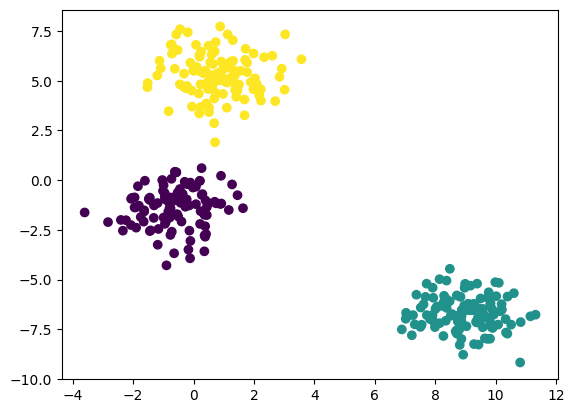

In [22]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [23]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [25]:
from gettext import install


!pip install kneed

In [26]:
from kneed import KneeLocator

In [27]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [28]:
kl.elbow

np.int64(3)

In [29]:
#shiloute score 

from sklearn.metrics import silhouette_score

In [30]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [31]:
silhouette_coefficients

[0.7359881221238582,
 0.7533601804729653,
 0.581590400464957,
 0.4506203102615459,
 0.345799712048232,
 0.3383909750293967,
 0.3479913869574166,
 0.3204888331462595,
 0.33379336062913356]

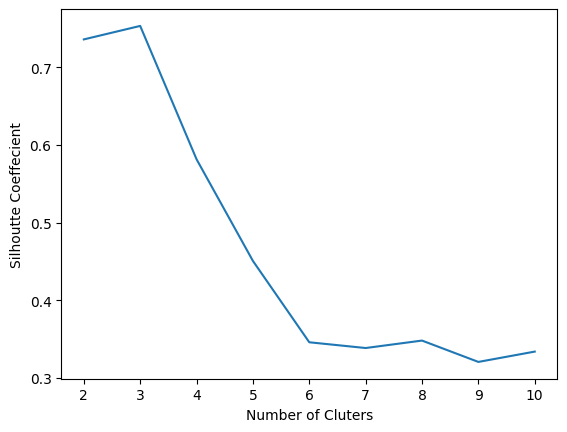

In [32]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()